<div style="display: flex; justify-content: flex-start; align-items: center;">
    <a href="https://colab.research.google.com/github/msfasha/307304-Data-Mining/blob/main/20252/Module%206-Time%20Series%20Analysis/2-time_series_processing_using_pandas.ipynb" target="_blank">    
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="height: 25px; margin-right: 20px;">
    </a>
</div>

# Part 2: Time Series Processing using Pandas

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">1) Import Libraries and Set Visual Theme</h2>
</div>

In this step, we import pandas for tabular time series manipulation and matplotlib for visualization.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">2) Load a Real Time Series Dataset</h2>
</div>

Here we load a real-world daily temperature dataset from a public source into a DataFrame.
We do this first to ground all later processing steps (resampling, rolling windows, lag features) on real observations instead of synthetic values.

In [6]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
raw_df = pd.read_csv(url)
raw_df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">3) Parse Date Column</h2>
</div>

In this step, we convert the Date column from plain text into pandas datetime objects.
We do this because time-aware operations in pandas (indexing by date, resampling, rolling by time, and plotting on a time axis) depend on correct datetime types.

In [3]:
raw_df['Date'] = pd.to_datetime(raw_df['Date'])
raw_df.dtypes

Date    datetime64[ns]
Temp           float64
dtype: object

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">4) Set Datetime Index</h2>
</div>

This block prepares a clean time-indexed DataFrame for all later time series operations.
The code in this cell validates dates, removes unusable rows, and then configures a chronological datetime index for time-based analysis.

In [ ]:
ts = raw_df.copy()
# Convert text dates to datetime; invalid values become missing datetimes (NaT).
ts['Date'] = pd.to_datetime(ts['Date'], errors='coerce')
# Remove rows where date parsing failed.
ts = ts.dropna(subset=['Date'])
# Use Date as a sorted time index for time series operations.
ts = ts.set_index('Date').sort_index().rename(columns={'Temp': 'temp_c'})
ts.head()

,temp_c
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">5) Inspect Series Span</h2>
</div>

This cell checks the dataset start date, end date, and total number of rows.
We verify this early so we know the historical coverage available and can later choose sensible rolling windows and train/test split points.

In [5]:
pd.Series({
    'start': ts.index.min(),
    'end': ts.index.max(),
    'rows': len(ts)
})

start    1981-01-01 00:00:00
end      1990-12-31 00:00:00
rows                    3650
dtype: object

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">Section A: Basic Visualization</h2>
</div>

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">6) Plot the Full Daily Series</h2>
</div>

We plot the full daily temperature series to get a first visual understanding of the data.
This helps us quickly detect broad trend, seasonality patterns, and possible anomalies before applying transformations.

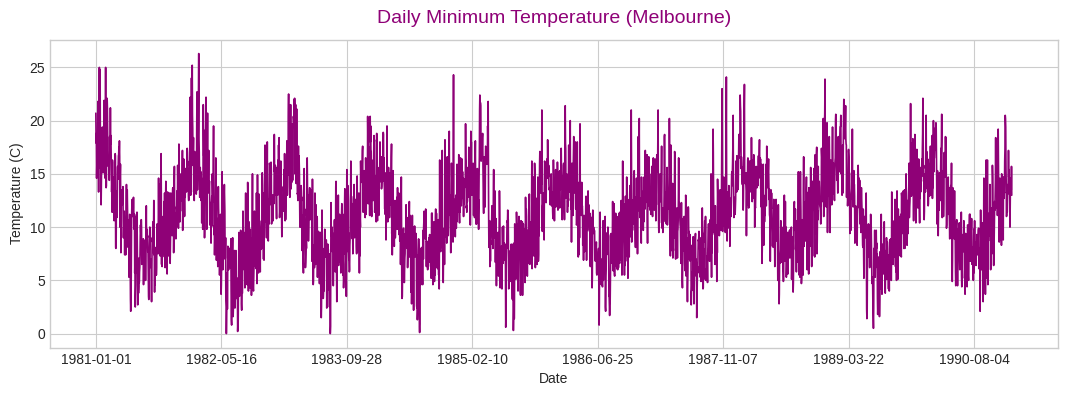

In [9]:
ax = ts['temp_c'].plot(figsize=(13, 4), linewidth=1.2)
ax.set_title('Daily Minimum Temperature (Melbourne)', fontsize=14, pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (C)')
plt.show()

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">7) Zoom Into a Single Year</h2>
</div>

Here we isolate one year (1984) and visualize it separately.
A focused yearly view makes local seasonal movement easier to interpret than the full multi-year chart.

In [ ]:
ts_safe = ts.copy()
# Ensure index is datetime so year-based filtering works safely.
ts_safe.index = pd.to_datetime(ts_safe.index, errors='coerce')
ts_safe = ts_safe[~ts_safe.index.isna()]

# Keep only rows from calendar year 1984.
ts_1984 = ts_safe.loc[ts_safe.index.year == 1984]
ax = ts_1984['temp_c'].plot(figsize=(13, 4), linewidth=1.4)
ax.set_title('Daily Minimum Temperature - Year 1984', fontsize=14, pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (C)')
plt.show()

KeyError: '1984'

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">Section B: Resampling</h2>
</div>

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">8) Compute Monthly Mean Temperature</h2>
</div>

In this cell, we resample daily values into monthly means.
We do this to reduce day-to-day noise and reveal medium-term seasonal behavior more clearly.

In [ ]:
# Aggregate daily observations into monthly average values.
monthly_mean = ts['temp_c'].resample('M').mean()
monthly_mean.head()

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">9) Plot Monthly Mean Series</h2>
</div>

We visualize the monthly mean series generated in the previous step.
This plot is useful to confirm whether the resampling produced a smoother signal with clearer seasonal cycles.

In [ ]:
ax = monthly_mean.plot(figsize=(13, 4), marker='o', markersize=3)
ax.set_title('Monthly Mean Temperature', fontsize=14, pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (C)')
plt.show()

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">10) Compute Quarterly Maximum Temperature</h2>
</div>

Here we resample by quarter and keep the maximum value in each quarter.
This complementary aggregation highlights warm-period peaks and shows how different resample statistics answer different questions.

In [ ]:
# Aggregate by quarter and keep the maximum value per quarter.
quarterly_max = ts['temp_c'].resample('Q').max()
quarterly_max.head()

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">Section C: Rolling Statistics</h2>
</div>

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">11) Calculate 30-Day Rolling Mean</h2>
</div>

We compute a rolling 30-day average over the daily series.
Rolling means are used to smooth short-term fluctuations and expose the local trend component.

In [ ]:
# For each day, average the current day and previous 29 days.
rolling_mean_30 = ts['temp_c'].rolling(window=30).mean()
rolling_mean_30.head(35).tail()

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">12) Calculate 30-Day Rolling Standard Deviation</h2>
</div>

This cell computes rolling 30-day standard deviation.
We use it to track local volatility, meaning how much temperature variability changes across time.

In [ ]:
# Measure local volatility across a 30-day moving window.
rolling_std_30 = ts['temp_c'].rolling(window=30).std()
rolling_std_30.head(35).tail()

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">13) Overlay Original vs 30-Day Rolling Mean</h2>
</div>

Now we plot the raw daily series together with the rolling mean.
This side-by-side overlay helps explain what smoothing removes (noise) and what it preserves (overall trend structure).

In [ ]:
ax = ts['temp_c'].plot(figsize=(13, 4), color='gray', alpha=0.45, linewidth=1, label='Daily')
# Plot onto the same axes so both series appear on one chart.
rolling_mean_30.plot(ax=ax, linewidth=2, label='30-Day Rolling Mean')
ax.set_title('Daily Signal vs Rolling Mean', fontsize=14, pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (C)')
ax.legend()
plt.show()

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">Section D: Transformations for Modeling</h2>
</div>

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">14) Create a 1-Day Lag Feature</h2>
</div>

In this step, we create a lag-1 feature, which stores yesterday's temperature for each date.
Lag features are a core idea in time series modeling because past values often help predict current or future values.

In [ ]:
lag_1 = ts['temp_c'].shift(1)
lag_1.head()

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">15) First-Order Differencing</h2>
</div>

Here we compute first-order difference, which is today's value minus yesterday's value.
We do this to focus on change dynamics and reduce persistent level effects in the original series.

In [ ]:
diff_1 = ts['temp_c'].diff(1)
diff_1.head()

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">16) Build a Simple Modeling Table</h2>
</div>

This cell combines original values and engineered features into one modeling-ready table.
The goal is to centralize useful predictors in a single DataFrame before splitting data for training and evaluation.

In [ ]:
features = pd.DataFrame({
    'temp_c': ts['temp_c'],
    'lag_1': lag_1,
    'rolling_mean_30': rolling_mean_30,
    'diff_1': diff_1
})
features.head()

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">Section E: Missing Values and Calendar Features</h2>
</div>

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">17) Reindex to Daily Frequency</h2>
</div>

We explicitly enforce daily frequency on the datetime index.
This creates a consistent calendar timeline, which is essential for detecting date gaps and performing robust interpolation.

In [ ]:
# Align to a daily calendar; missing days are inserted as NaN.
full_daily = ts.asfreq('D')
full_daily.head()

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">18) Count Missing Values</h2>
</div>

This cell counts missing temperature values after frequency enforcement.
We check this to quantify data quality issues before choosing a fill strategy.

In [ ]:
full_daily['temp_c'].isna().sum()

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">19) Fill Missing Values with Time Interpolation</h2>
</div>

Here we fill missing observations using time-based interpolation.
This method uses neighboring dates to create plausible values while preserving temporal continuity better than a constant fill.

In [ ]:
filled = full_daily.copy()
# Fill missing values by interpolating along the time axis.
filled['temp_c'] = filled['temp_c'].interpolate(method='time')
filled.head()

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">20) Add Day-of-Week Feature</h2>
</div>

In this step, we extract the weekday name from each timestamp.
Calendar features like day-of-week can help capture recurring weekly effects in downstream models.

In [ ]:
filled['day_of_week'] = filled.index.day_name()
filled[['temp_c', 'day_of_week']].head()

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">21) Compute Average Temperature by Day of Week</h2>
</div>

We aggregate by weekday and compute the mean temperature for each day name.
This gives a compact weekly seasonality summary and helps interpret whether certain weekdays are systematically warmer or cooler.

In [ ]:
# Compute mean temperature by weekday and enforce Monday-to-Sunday order.
dow_avg = filled.groupby('day_of_week')['temp_c'].mean().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])
dow_avg

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">Section F: Time-Aware Train/Test Split</h2>
</div>

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">22) Split Chronologically (No Shuffle)</h2>
</div>

This cell splits the series into train and test sets by time order (first 80 percent, last 20 percent).
We never shuffle in time series because preserving chronology is required to avoid leakage from future data into training.

In [ ]:
# Set the split point at 80% of the timeline length.
split_idx = int(len(filled) * 0.8)
# Use past data for training and later data for testing (no shuffle).
train = filled.iloc[:split_idx].copy()
test = filled.iloc[split_idx:].copy()
(train.shape, test.shape)

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">23) Visualize the Train/Test Boundary</h2>
</div>

We plot train and test segments on the same timeline.
This visual check confirms that the split boundary is chronological and that the test segment truly represents future observations.

In [ ]:
ax = train['temp_c'].plot(figsize=(13, 4), label='Train')
test['temp_c'].plot(ax=ax, color='black', alpha=0.7, label='Test')
ax.set_title('Chronological Train/Test Split', fontsize=14, pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (C)')
ax.legend()
plt.show()

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">Section G: Wrap-Up</h2>
</div>

<div style="background:#8F0177;color:white;padding:14px 18px;border-radius:10px;">
  <h2 style="margin:0;">24) Final Processed Dataset Preview</h2>
</div>

Finally, we assemble a compact feature table and preview the first valid rows.
This confirms all engineered columns are aligned and ready for the next stage, such as forecasting or regression modeling.

In [ ]:
final_df = filled[['temp_c']].copy()
# Previous day value (lag feature).
final_df['lag_1'] = final_df['temp_c'].shift(1)
# Day-to-day change.
final_df['diff_1'] = final_df['temp_c'].diff(1)
# 30-day local trend.
final_df['rolling_mean_30'] = final_df['temp_c'].rolling(30).mean()
final_df['day_of_week'] = final_df.index.day_name()
# Remove initial rows that are incomplete due to lag/diff/rolling.
final_df.dropna().head(10)